In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.csv')
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [26]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

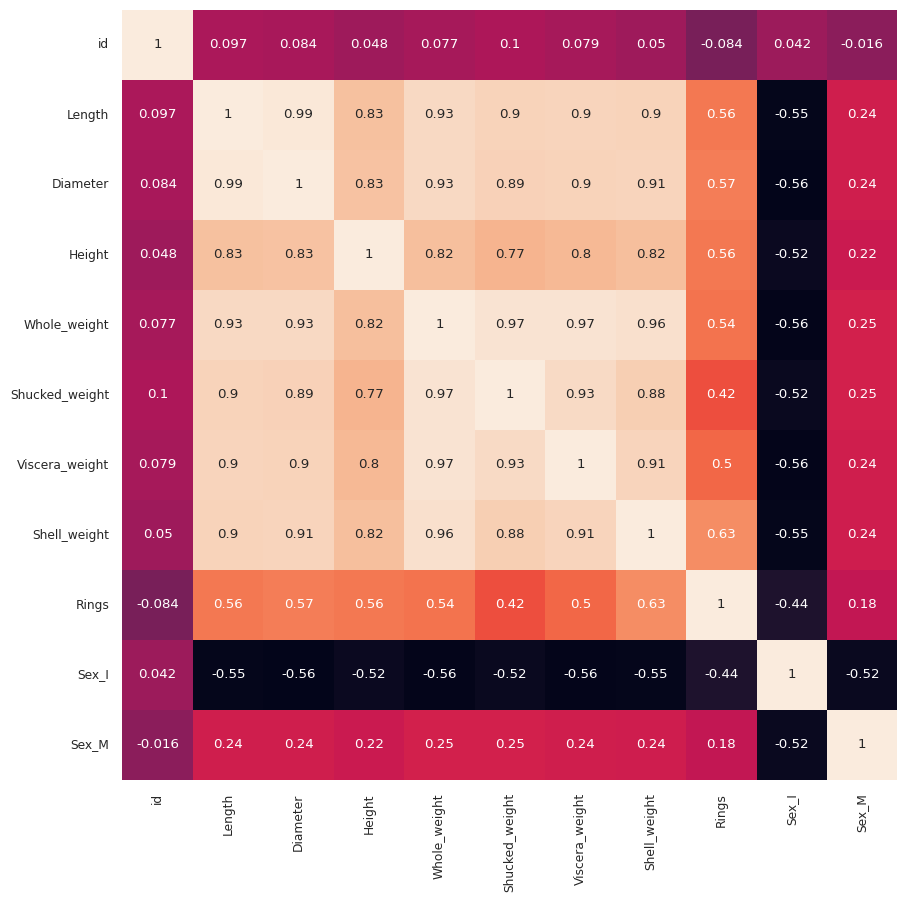

In [27]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [28]:
X = df.drop('Rings',axis=1).values
y = df['Rings'].values

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])


model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 39.0027 - mae: 4.9148 - val_loss: 7.6177 - val_mae: 1.9468
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.4889 - mae: 1.6996 - val_loss: 5.5711 - val_mae: 1.6901
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0532 - mae: 1.6102 - val_loss: 5.2441 - val_mae: 1.6256
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4556 - mae: 1.5751 - val_loss: 5.1794 - val_mae: 1.6383
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0909 - mae: 1.5548 - val_loss: 5.0069 - val_mae: 1.5872
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9108 - mae: 1.5455 - val_loss: 5.1114 - val_mae: 1.6442
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6934 - mae: 1.5230 - val_loss: 4.9577 - val_mae: 1.6130
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.5485 - mae: 1.5210 - val_loss: 4.9802 - val_mae: 1.6035
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

In [33]:
y_pred = model.predict(X_test).flatten()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


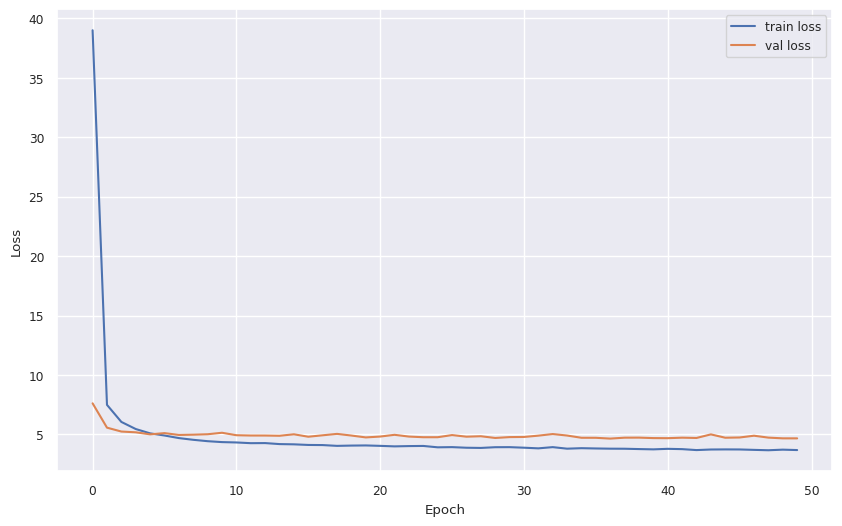

In [34]:
# loss 체크
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

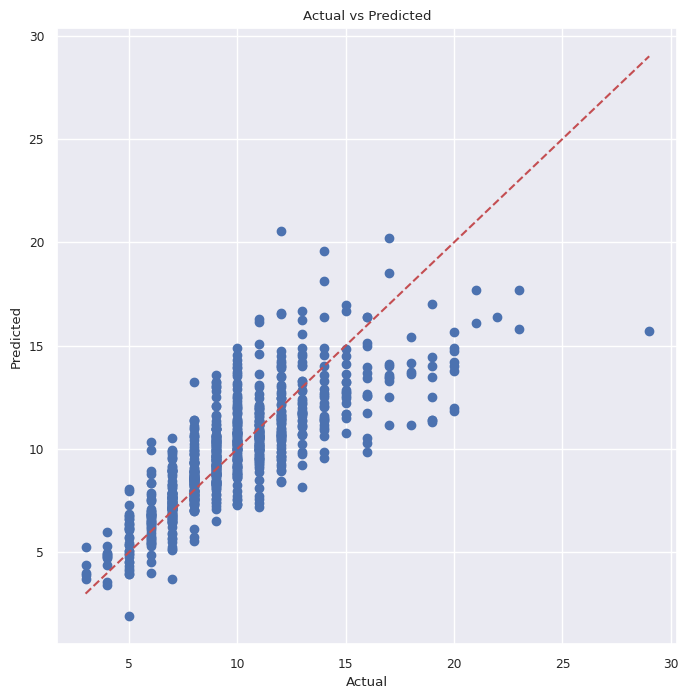

In [35]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()